In [1]:
import sys
import platform
import warnings

# -------------------------------------------------------------------------
# 1. Google Colab / 리눅스 환경 한글 폰트(나눔고딕) 강제 설치 및 캐시 초기화
# -------------------------------------------------------------------------
# Darwin(macOS)이 아닌 리눅스 기반 환경(Colab)일 때만 시스템 폰트를 다운로드합니다.
if sys.platform != 'darwin':
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null


Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats

import sklearn
from sklearn.datasets import make_classification # 정형 데이터 분류 데이터셋 가상생성위해
from sklearn.model_selection import(
    train_test_split,
    GridSearchCV, # 최적 하이퍼 파라미터 탐색 격자 수행 도구
    StratifiedKFold, # 교차 검증 (타겟 클래스의 비율을 유지하며 분할 / KFold랑 차이 O)
    cross_validate # 교차 검증 세부 지표 다중 평가 (학습시간, 복수평가지표 등)
)

from sklearn.pipeline import Pipeline # 전처리 + 모델링 하나로 결합 파이프라인
from sklearn.compose import ColumnTransformer # 변수 속성(수치형 / 범주형)별로 전처리를 조준 실행 변환기
from sklearn.impute import SimpleImputer # 결측치 보간

# 전처리 라이브러리
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression # 분류 알고리즘 (로지스틱 회귀)
from sklearn.ensemble import RandomForestClassifier # 여러개 트리 앙상블 (분류 정확도 및 안정성 ↑)
from sklearn.metrics import (
    classification_report, # Precision, Recall, F1-score 세부 리포트 생성
    confusion_matrix, # 혼돈 행렬 원본 데이터 도출
    ConfusionMatrixDisplay, # 혼돈 행렬 시각화 툴
    roc_auc_score # 불균형 데이터셋 분류력 측정 (ROC-AUC 스코어 산출)
)

# 7. 설치된 나눔 폰트를 Matplotlib 환경에 등록
# -------------------------------------------------------------------------
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# -------------------------------------------------------------------------
# 8. 차트 스타일, 한글 깨짐 및 마이너스 기호 깨짐 방지 글로벌 설정
# -------------------------------------------------------------------------
# - font.family: Colab 리눅스에 강제 매핑된 'NanumBarunGothic' 폰트 지정
# - axes.unicode_minus: 음수(-) 부호가 깨져 네모(☐)로 표기되는 현상 방지
# - figure.dpi: 고해상도 모니터 및 Colab 환경 내 가독성 향상을 위해 인치당 픽셀 수를 110으로 선명화
plt.rcParams.update({
    'font.family': 'NanumBarunGothic',
    'axes.unicode_minus': False,
    'figure.dpi': 110
})

# Seaborn 테마 설정: 깔끔한 격자무늬(whitegrid) 스타일로 통일하고 한글 폰트 적용
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

# -------------------------------------------------------------------------
# 9. 결과의 완벽한 재현성(Reproducibility) 확보를 위한 난수 시드 고정
# -------------------------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('==================================================================')
print(f'▶ 환경 설정 및 전처리 라이브러리 통합 로드 완료 (Sklearn V-{sklearn.__version__})')
print('▶ Google Colab 내 나눔바른고딕 한글 폰트 최적화 셋업 성공')
print('==================================================================')

▶ 환경 설정 및 전처리 라이브러리 통합 로드 완료 (Sklearn V-1.6.1)
▶ Google Colab 내 나눔바른고딕 한글 폰트 최적화 셋업 성공


In [3]:
titanic = sns.load_dataset('titanic')

print('shape : ', titanic.shape)
print('컬럼 : ', titanic.columns.tolist())

titanic.head(10)

shape :  (891, 15)
컬럼 :  ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [4]:
# 독립변수랑 종속변수를 정해보자
# 처음 분류 모델 만들 땐 해석 가능한 일부 변수로 시작하는 것이 좋다고 했으니 그렇게 해보자

base_features = [
    # 숫자형부터
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare',

    # 이제 범주형
    'sex',
    'embarked',
    'who',
    'adult_male',
    'alone'
]

# 예측할 대상 (y = 종속변수)
target = 'survived'

X = titanic.loc[:, base_features].copy() # 원본을 보존하는게 좋으니 copy 해두자
y = titanic.loc[:, target].copy()

print('X_shape : ', X.shape)
print('y_shape : ', y.shape)

print(y.value_counts().sort_index())

X_shape :  (891, 10)
y_shape :  (891,)
survived
0    549
1    342
Name: count, dtype: int64


In [11]:
X_train,  X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = RANDOM_STATE,
    stratify = y # 분류문제에선 적어주는게 좋음 (train / test에 종속변수 비율을 비슷하게 만들어줌)
)

print(f"학습 데이터 : {len(X_train)}건")
print(f"테스트 데이터 : {len(X_test)}건")
print(f"X_train 결측치 : \n{X_train.isnull().sum()}")

학습 데이터 : 712건
테스트 데이터 : 179건
X_train 결측치 : 
pclass          0
age           137
sibsp           0
parch           0
fare            0
sex             0
embarked        2
who             0
adult_male      0
alone           0
dtype: int64


In [12]:
# 수치형 변수랑 범주형 변수를 서로 분리하자
numeric_features = [
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare',
]

categorical_features = [
    'sex',
    'embarked',
    'who',
    'adult_male',
    'alone'
]



In [14]:
# 이제 파이프라인을 구성해보자
# 먼저 수치형 특성
numeric_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'median')), # 결측치를 중앙값으로 보간
    ('scaler', StandardScaler())
])

# 다음은 범주
categorical_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')), # 최빈값으로 보간
    ('onehot', OneHotEncoder(drop = 'first', handle_unknown = 'ignore', sparse_output = False))
])

# 전처리 설계도 - ColumnTransformer 사용
preprocessor = ColumnTransformer(transformers = [
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# 모델 정의 (하이퍼파라미터 설정)
RF_model = RandomForestClassifier(
    n_estimators = 200,
    random_state = RANDOM_STATE,
    n_jobs = -1
)

pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('model', RF_model)
])

In [16]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sex', 'embarked', 'who',
                                                   'adult_male', 'alone'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [17]:
# 교차 검증도 해보자 (모델이 데이터만 외운게 아니라 새로운 데이터에 있어서도 잘 맞출 수 있는지 검증)
cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = RANDOM_STATE
)

scoring = {
    'accuracy' : 'accuracy',
    'f1' : 'f1',
    'roc_auc' : 'roc_auc',
    'recall' : 'recall'
}

cv_result = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv = cv,
    scoring = scoring,
    return_train_score = True,
    n_jobs = -1
)
cv_result

{'fit_time': array([0.96691179, 0.71575809, 0.67705441, 0.63913536, 0.54669333]),
 'score_time': array([0.15227199, 0.1528163 , 0.16584039, 0.14787316, 0.14582348]),
 'test_accuracy': array([0.7972028 , 0.79020979, 0.82394366, 0.78873239, 0.81690141]),
 'train_accuracy': array([0.97891037, 0.98594025, 0.98070175, 0.98070175, 0.98596491]),
 'test_f1': array([0.73394495, 0.73214286, 0.76190476, 0.73684211, 0.74509804]),
 'train_f1': array([0.97235023, 0.98139535, 0.97459584, 0.97447796, 0.98165138]),
 'test_roc_auc': array([0.85113636, 0.85454545, 0.87742947, 0.87868266, 0.87142256]),
 'train_roc_auc': array([0.9975692 , 0.9979678 , 0.99752398, 0.99830881, 0.9988552 ]),
 'test_recall': array([0.72727273, 0.74545455, 0.72727273, 0.77777778, 0.7037037 ]),
 'train_recall': array([0.96788991, 0.96788991, 0.96788991, 0.95890411, 0.97716895])}

In [26]:
cv_result_df = pd.DataFrame(cv_result)

test_results = cv_result_df.filter(like='test_')

test_results.agg(['mean', 'std']).T

,mean,std
test_accuracy,0.803398,0.016061
test_f1,0.741987,0.012191
test_roc_auc,0.866643,0.012951
test_recall,0.736296,0.027521


In [28]:
# test 데이터에 대해 평가지표가 썩 별로다 하이퍼파라미터 튜닝해보자

param_grid = {
    'model__n_estimators' : [100 ,200],
    'model__max_depth' : [3, 5, None],
    'model__min_samples_leaf' : [1, 3, 5],
    'model__max_features' : ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator = pipeline,
    param_grid = param_grid,
    scoring = 'roc_auc',
    cv = cv,
    n_jobs = -1,
    return_train_score = True # 결과물(grid_search.cv_results_)에 테스트 점수뿐만 아니라 학습(Train) 점수도 같이 기록
)

grid_search.fit(X_train, y_train)

print(grid_search.best_score_)
print(grid_search.best_params_)

0.8800158323042335
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 100}


In [30]:
tuning_df = pd.DataFrame(grid_search.cv_results_)
tuning_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__max_depth,param_model__max_features,param_model__min_samples_leaf,param_model__n_estimators,params,split0_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.544694,0.097441,0.133191,0.016837,3,sqrt,1,100,"{'model__max_depth': 3, 'model__max_features':...",0.884504,...,0.869860,0.023865,23,0.883139,0.896573,0.877769,0.888329,0.890216,0.887205,0.006382
1,1.004679,0.109370,0.120262,0.025892,3,sqrt,1,200,"{'model__max_depth': 3, 'model__max_features':...",0.885331,...,0.867578,0.023861,31,0.884524,0.896371,0.878519,0.888577,0.890255,0.887649,0.005947
2,0.302256,0.015169,0.051537,0.003713,3,sqrt,3,100,"{'model__max_depth': 3, 'model__max_features':...",0.884298,...,0.870108,0.022780,19,0.882165,0.894358,0.877965,0.887542,0.889273,0.886261,0.005690
3,0.562935,0.016951,0.071130,0.001844,3,sqrt,3,200,"{'model__max_depth': 3, 'model__max_features':...",0.886157,...,0.869187,0.024324,27,0.884112,0.894535,0.879046,0.888687,0.889247,0.887125,0.005219
4,0.296420,0.005063,0.053818,0.007987,3,sqrt,5,100,"{'model__max_depth': 3, 'model__max_features':...",0.881612,...,0.869547,0.022831,25,0.881753,0.895110,0.876479,0.885884,0.888336,0.885512,0.006260
5,0.580381,0.019891,0.070764,0.001009,3,sqrt,5,200,"{'model__max_depth': 3, 'model__max_features':...",0.884091,...,0.868108,0.023644,29,0.883511,0.894312,0.878714,0.888069,0.888967,0.886715,0.005271
6,0.301812,0.012303,0.050156,0.001406,3,log2,1,100,"{'model__max_depth': 3, 'model__max_features':...",0.884504,...,0.869860,0.023865,23,0.883139,0.896573,0.877769,0.888329,0.890216,0.887205,0.006382
7,0.573906,0.014462,0.075812,0.007189,3,log2,1,200,"{'model__max_depth': 3, 'model__max_features':...",0.885331,...,0.867578,0.023861,31,0.884524,0.896371,0.878519,0.888577,0.890255,0.887649,0.005947
8,0.303061,0.013976,0.050539,0.000884,3,log2,3,100,"{'model__max_depth': 3, 'model__max_features':...",0.884298,...,0.870108,0.022780,19,0.882165,0.894358,0.877965,0.887542,0.889273,0.886261,0.005690
9,0.958090,0.123512,0.131875,0.017591,3,log2,3,200,"{'model__max_depth': 3, 'model__max_features':...",0.886157,...,0.869187,0.024324,27,0.884112,0.894535,0.879046,0.888687,0.889247,0.887125,0.005219


In [31]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

In [35]:
y_proba[:, 1]

array([0.12850826, 0.08897831, 0.12649778, 0.07699073, 0.62506704,
       0.39270786, 0.88587236, 0.59487606, 0.44148901, 0.1189237 ,
       0.13681106, 0.12872308, 0.42848237, 0.18854573, 0.28356171,
       0.11148949, 0.23688733, 0.04228283, 0.11408616, 0.90462236,
       0.04228283, 0.8438735 , 0.20490984, 0.44564071, 0.12253327,
       0.97267411, 0.13681106, 0.38838549, 0.11717466, 0.14590359,
       0.17636925, 0.98115303, 0.21161669, 0.08472191, 0.51452935,
       0.67601911, 0.50390437, 0.28461044, 0.13681106, 0.88490628,
       0.29428276, 0.8814484 , 0.10722865, 0.87096899, 0.90313923,
       0.10217845, 0.10129295, 0.27974449, 0.69980516, 0.90016884,
       0.99371368, 0.38345093, 0.81292264, 0.04718511, 0.32793178,
       0.09094546, 0.08695566, 0.5986315 , 0.61993122, 0.58670853,
       0.48437163, 0.89740256, 0.19031753, 0.13726865, 0.44663806,
       0.37045504, 0.99237541, 0.17987369, 0.19205781, 0.03867361,
       0.95574968, 0.10249768, 0.69894508, 0.96746936, 0.12266

In [39]:
test_roc_auc = roc_auc_score(y_test, y_proba[:, 1])
round(test_roc_auc, 4)

np.float64(0.8457)

In [42]:
print(classification_report(y_test, y_pred, target_names = ['사망', '생존']))

              precision    recall  f1-score   support

          사망       0.82      0.93      0.87       110
          생존       0.85      0.68      0.76        69

    accuracy                           0.83       179
   macro avg       0.84      0.80      0.81       179
weighted avg       0.83      0.83      0.83       179



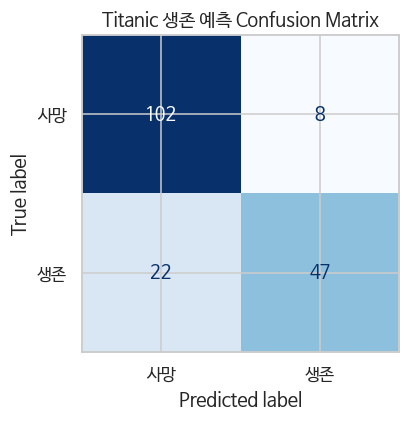

In [43]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['사망', '생존']).plot(
    ax=ax,
    cmap='Blues',
    colorbar=False,
)
ax.set_title('Titanic 생존 예측 Confusion Matrix')
plt.tight_layout()
plt.show()


In [44]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
importances = best_model.named_steps['model'].feature_importances_

In [48]:
importance_df = pd.DataFrame({
    'feature' : feature_names,
    'importance' : importances,
}).sort_values('importance', ascending = False)

importance_df.head()

,feature,importance
4,num__fare,0.157333
10,cat__adult_male_True,0.146170
8,cat__who_man,0.146051
5,cat__sex_male,0.133868
0,num__pclass,0.124075


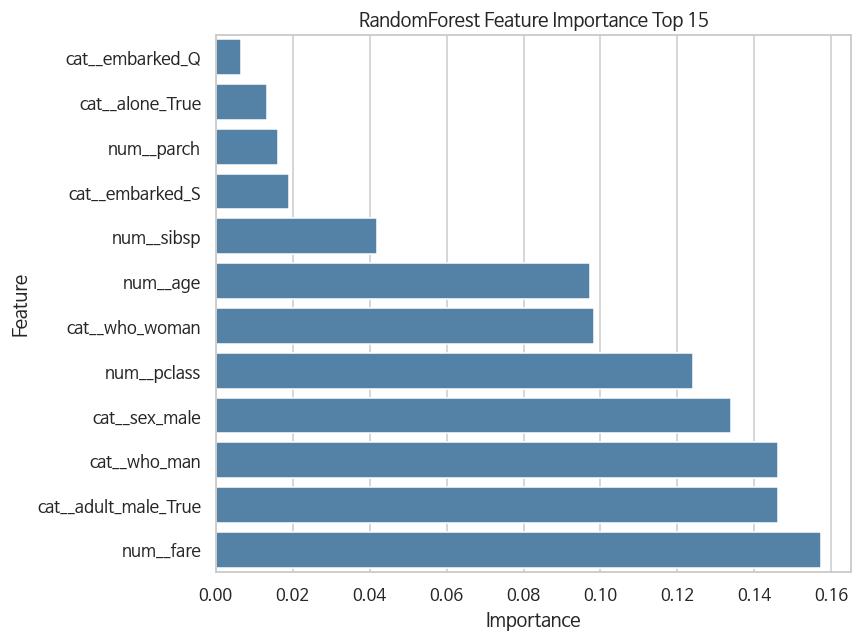

In [49]:
top_importance = importance_df.head(15).sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=top_importance, x='importance', y='feature', ax=ax, color='steelblue')
ax.set_title('RandomForest Feature Importance Top 15')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()